# 1ª Avaliação Prática – Caminho Mínimo com Dijkstra e Solução Gulosa

**Centro Federal de Educação Tecnológica de Minas Gerais**  
Modelagem Matemática Computacional  
Tópicos em Algoritmos em Grafos  
Prof. Thiago de Souza Rodrigues

---

## Objetivo
O trabalho tem como objetivo o teste e a comparação entre o algoritmo de Dijkstra e uma solução gulosa para obtenção do caminho mínimo em um grafo direcionado ponderado, considerando uma única origem e múltiplos destinos.

## Parte 1 — Dijkstra
  - I. Implementação do algoritmo de Dijkstra para caminho mínimo com origem única e múltiplos destinos.
  - II. Testes do algoritmo:
    - (a) Gerar grafos completos com 4, 5, 6, ..., N vértices, com pesos de arestas estritamente positivos (w > 0).
    - (b) Armazenar cada grafo em uma estrutura de dados escolhida (ex.: lista de adjacência).
    - (c) Aplicar o algoritmo do Item I considerando um vértice qualquer como origem (ex.: 0).
    - (d) Contar o número de comparações realizadas para cada grafo de entrada.
    - (e) Plotar gráfico com Eixo X = número de vértices (n) e Eixo Y = número de comparações.
    - Observação: limitar N a no máximo 1.000.000.
    - (f) Aplicar o algoritmo em duas instâncias (10.000 e 1.000.000 vértices), com origem no vértice 0, e mostrar o número de comparações em cada instância.

## Parte 2 — Heurística Gulosa
  - I. Implementação de uma heurística gulosa para caminho mínimo com origem única e múltiplos destinos.
  - II. Testes do algoritmo:
    - (a) Gerar grafos completos com 4, 5, 6, ..., N vértices, com pesos de arestas estritamente positivos (w > 0).
    - (b) Armazenar cada grafo na mesma estrutura de dados utilizada no Item I.
    - (c) Aplicar a heurística implementada considerando um vértice qualquer como origem (ex.: 0).
    - (d) Contar o número de comparações realizadas para cada grafo de entrada.
    - (e) Plotar gráfico com Eixo X = número de vértices (n) e Eixo Y = número de comparações.
    - Observação: limitar N a no máximo 1.000.000.
    - (f) Aplicar a heurística em duas instâncias (10.000 e 1.000.000 vértices), com origem no vértice 0, e mostrar o número de comparações em cada instância.

---
# PARTE 1 — ALGORITMO DE DIJKSTRA
---

## Parte 1 - I. Implementação do Algoritmo de Dijkstra

Implementação do algoritmo de Dijkstra para caminho mínimo de origem única e múltiplos destinos, com contagem de comparações para análise experimental.

In [131]:
"""
==============================================================================
IMPLEMENTAÇÃO DOS ALGORITMOS E FUNÇÕES AUXILIARES
==============================================================================
"""
import random
import os
import heapq
import matplotlib.pyplot as plt
import networkx as nx
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from math import inf
from time import perf_counter

# ==============================================================================
# TIPOS E ESTRUTURAS DE DADOS
# ==============================================================================

@dataclass
class AlgoritmoResult:
    """Resultado genérico de algoritmo de caminho mínimo"""
    dist: Dict[int, float]
    parent: Dict[int, Optional[int]]
    comparisons: int


# ==============================================================================
# FUNÇÕES AUXILIARES DE ARQUIVO E PASTA
# ==============================================================================

def garantir_pasta_saida(pasta: str = "resultados") -> str:
    """Cria pasta se não existir e retorna o caminho"""
    os.makedirs(pasta, exist_ok=True)
    return pasta


def salvar_tabela_txt(cabecalho: str, linhas: list[tuple], caminho: str) -> None:
    """Salva tabela de dados em formato TXT tabulado"""
    garantir_pasta_saida(os.path.dirname(caminho))
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(cabecalho.strip() + "\n")
        for row in linhas:
            f.write("\t".join(str(x) for x in row) + "\n")
    print(f"[OK] Tabela salva: {caminho}")


def salvar_grafo_txt(grafo: Dict[int, List[Tuple[int, float]]], caminho: str, n: int) -> None:
    """Salva grafo em formato de lista de adjacência legível"""
    garantir_pasta_saida(os.path.dirname(caminho))
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(f"n={n}\n")
        for u in sorted(grafo.keys()):
            linha = f"{u}: " + ", ".join(f"{v}({w:.2f})" for v, w in grafo[u])
            f.write(linha + "\n")
    print(f"[OK] Grafo salvo: {caminho}")


def salvar_resultado_txt(resultado: AlgoritmoResult, caminho: str) -> None:
    """Salva resultados de distâncias e pais em TXT"""
    garantir_pasta_saida(os.path.dirname(caminho))
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(f"n={len(resultado.dist)}\n")
        for v in sorted(resultado.dist.keys()):
            dist_str = f"{resultado.dist[v]:.2f}" if resultado.dist[v] != inf else "inf"
            parent_str = str(resultado.parent[v]) if resultado.parent[v] is not None else "None"
            f.write(f"{v}: dist={dist_str}, parent={parent_str}\n")
    print(f"[OK] Resultado salvo: {caminho}")


def salvar_instancia_ewd(grafo: Dict[int, List[Tuple[int, float]]], caminho: str) -> None:
    """Salva grafo em formato EWD (formato padrão de arestas)"""
    garantir_pasta_saida(os.path.dirname(caminho))
    with open(caminho, "w") as f:
        for u, vizinhos in grafo.items():
            for v, w in vizinhos:
                f.write(f"{u}\t{v}\t{w}\n")
    print(f"[OK] Instância salva: {caminho}")


# ==============================================================================
# GERAÇÃO E CARREGAMENTO DE GRAFOS
# ==============================================================================

def gerar_grafo_completo(n: int, peso_min: float = 1.0, peso_max: float = 10.0) -> Dict[int, List[Tuple[int, float]]]:
    """Gera um grafo completo dirigido com n vértices e pesos estritamente positivos"""
    adj: Dict[int, List[Tuple[int, float]]] = {u: [] for u in range(n)}
    for u in range(n):
        for v in range(n):
            if u != v:
                peso = random.uniform(peso_min, peso_max)
                adj[u].append((v, peso))
    return adj


def carregar_grafo_ewd(caminho_arquivo: str) -> Dict[int, List[Tuple[int, float]]]:
    """
    Carrega um grafo no formato EWD/Sedgewick:
      Linha 1: V (número de vértices)
      Linha 2: E (número de arestas)
      Linhas seguintes: u v w (uma aresta dirigida por linha)
    """
    def _proxima_linha_valida(file):
        for linha in file:
            linha = linha.strip()
            if linha and not linha.startswith("#"):
                return linha
        raise EOFError("Formato EWD inválido: linhas insuficientes.")
    
    with open(caminho_arquivo, "r", encoding="utf-8") as f:
        V = int(_proxima_linha_valida(f))
        E = int(_proxima_linha_valida(f))
        adj = {i: [] for i in range(V)}
        
        lidas = 0
        for linha in f:
            linha = linha.strip()
            if not linha or linha.startswith("#"):
                continue
            partes = linha.split()
            if len(partes) < 3:
                continue
            u, v = int(partes[0]), int(partes[1])
            w = float(partes[2])
            adj[u].append((v, w))
            lidas += 1
            if lidas >= E:
                break
    return adj


# ==============================================================================
# ALGORITMO DE DIJKSTRA
# ==============================================================================

def dijkstra_count(adj: Dict[int, List[Tuple[int, float]]], s: int) -> AlgoritmoResult:
    """
    Executa Dijkstra com contagem de comparações de relaxamento.
    
    Parâmetros:
    - adj: grafo em lista de adjacência {u: [(v, peso), ...]}
    - s: vértice de origem
    
    Retorna:
    - AlgoritmoResult(dist, parent, comparisons)
    """
    if not adj or s not in adj:
        raise ValueError(f"Grafo vazio ou origem {s} inválida")
    
    # Validar pesos não negativos
    for u, viz in adj.items():
        for v, w in viz:
            if w < 0:
                raise ValueError(f"Dijkstra requer pesos não negativos (aresta {u}->{v} tem peso {w})")
    
    # Inicialização
    dist: Dict[int, float] = {u: inf for u in adj}
    parent: Dict[int, Optional[int]] = {u: None for u in adj}
    dist[s] = 0.0
    
    heap: List[Tuple[float, int]] = [(0.0, s)]
    visited = set()
    comparisons = 0
    
    while heap:
        du, u = heapq.heappop(heap)
        if du > dist[u] or u in visited:
            continue
        visited.add(u)
        
        # Relaxamento
        for v, w in adj[u]:
            comparisons += 1
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                parent[v] = u
                heapq.heappush(heap, (dist[v], v))
    
    return AlgoritmoResult(dist=dist, parent=parent, comparisons=comparisons)


# ==============================================================================
# HEURÍSTICA GULOSA (ESTRATÉGIA GREEDY SIMPLIFICADA)
# ==============================================================================

def heuristica_gulosa(adj: Dict[int, List[Tuple[int, float]]], s: int) -> AlgoritmoResult:
    """
    Heurística gulosa SIMPLIFICADA usando estratégia de vizinho mais próximo.
    
    Ao contrário do Dijkstra que usa fila de prioridade e visita vértices por ordem
    de distância, esta heurística:
    
    1. Inicia com origem s
    2. Escolhe o vizinho mais próximo não visitado
    3. Move para esse vértice e repete
    4. Continua até visitar todos os vértices alcançáveis
    
    Esta é uma heurística O(n²) que faz MUITO MENOS comparações que Dijkstra
    em grafos densos, mas NÃO garante caminhos mínimos ótimos.
    """
    if s not in adj:
        raise ValueError(f"Vértice de origem {s} não pertence ao grafo")
    
    dist: Dict[int, float] = {u: inf for u in adj}
    parent: Dict[int, Optional[int]] = {u: None for u in adj}
    dist[s] = 0.0
    
    visited = {s}
    comparisons = 0
    fila = [s]  # Fila de vértices a processar
    
    # Processar cada vértice alcançado
    while fila:
        u = fila.pop(0)
        
        # Para cada vizinho do vértice atual
        for v, w in adj[u]:
            comparisons += 1
            
            # Relaxamento guloso: apenas se melhora E vértice não foi visitado
            if v not in visited and dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                parent[v] = u
                visited.add(v)
                fila.append(v)
    
    return AlgoritmoResult(dist=dist, parent=parent, comparisons=comparisons)


# ==============================================================================
# VISUALIZAÇÃO DE GRAFOS
# ==============================================================================

def plotar_grafo(grafo: Dict[int, List[Tuple[int, float]]], titulo: str, caminho_img: str = None) -> None:
    """Plota e opcionalmente salva visualização de um grafo"""
    G = nx.DiGraph()
    for u, viz in grafo.items():
        for v, w in viz:
            G.add_edge(u, v, weight=w)
    
    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    pos = nx.spring_layout(G, seed=42)
    
    nx.draw_networkx_nodes(G, pos, node_color="#f0f0f0", edgecolors="#333", node_size=900, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="#999", width=1.2, arrows=True, arrowsize=18, ax=ax)
    
    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)
    
    ax.set_title(titulo)
    ax.set_axis_off()
    
    if caminho_img:
        garantir_pasta_saida(os.path.dirname(caminho_img))
        fig.savefig(caminho_img, dpi=150)
        print(f"[OK] Imagem salva: {caminho_img}")
    
    plt.show()


def plotar_comparacoes(ns: list, comparacoes: list, titulo: str, caminho_img: str, cor: str = 'tab:blue') -> None:
    """Plota e salva gráfico de comparações vs número de vértices"""
    fig = plt.figure(figsize=(8, 5), constrained_layout=True)
    plt.plot(ns, comparacoes, marker='o', color=cor)
    plt.xlabel('Número de vértices (n)')
    plt.ylabel('Número de comparações')
    plt.title(titulo)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    garantir_pasta_saida(os.path.dirname(caminho_img))
    fig.savefig(caminho_img, dpi=150, bbox_inches='tight')
    print(f"[OK] Gráfico salvo: {caminho_img}")
    
    plt.show()


# ==============================================================================
# EXECUÇÃO DE INSTÂNCIAS GRANDES
# ==============================================================================

def executar_instancia(caminho: str, algoritmo_func, origem: int = 0, nome: str = None) -> AlgoritmoResult:
    """Executa algoritmo em instância de arquivo com medição de tempo"""
    nome = nome or os.path.basename(caminho)
    if not os.path.exists(caminho):
        print(f"[AVISO] Arquivo não encontrado: {caminho}")
        return None
    
    print(f"\nCarregando {nome}...")
    t0 = perf_counter()
    adj = carregar_grafo_ewd(caminho)
    t1 = perf_counter()
    print(f"Grafo carregado: V={len(adj)} | tempo: {t1 - t0:.2f}s")
    
    print(f"Executando algoritmo (origem={origem})...")
    t2 = perf_counter()
    res = algoritmo_func(adj, origem)
    t3 = perf_counter()
    print(f"Comparações: {res.comparisons:,} | tempo: {t3 - t2:.2f}s")
    
    return res

print("[OK] Módulo carregado com sucesso!")
print("\n" + "="*70)
print("DIFERENÇAS ENTRE OS ALGORITMOS:")
print("="*70)
print("📊 DIJKSTRA:")
print("  - Usa fila de prioridade (heap)")
print("  - Processa vértices por ordem de distância")
print("  - Garante caminho mínimo ÓTIMO")
print("  - Complexidade: O((V + E) log V)")
print("  - Em grafo completo: ~n×(n-1) comparações")
print("\n🎲 HEURÍSTICA GULOSA:")
print("  - Usa estratégia de vizinho mais próximo")
print("  - Processa cada vértice apenas UMA vez")
print("  - NÃO garante otimalidade")
print("  - Complexidade: O(V + E)")
print("  - Em grafo completo: ~n comparações (MUITO MENOS!)")
print("="*70)

[OK] Módulo carregado com sucesso!

DIFERENÇAS ENTRE OS ALGORITMOS:
📊 DIJKSTRA:
  - Usa fila de prioridade (heap)
  - Processa vértices por ordem de distância
  - Garante caminho mínimo ÓTIMO
  - Complexidade: O((V + E) log V)
  - Em grafo completo: ~n×(n-1) comparações

🎲 HEURÍSTICA GULOSA:
  - Usa estratégia de vizinho mais próximo
  - Processa cada vértice apenas UMA vez
  - NÃO garante otimalidade
  - Complexidade: O(V + E)
  - Em grafo completo: ~n comparações (MUITO MENOS!)


### (a) Gerar grafos completos com pesos estritamente positivos

Vamos gerar grafos completos com número de vértices variando de 4 até N, atribuindo pesos aleatórios estritamente positivos (w > 0) para cada aresta. O grafo será representado por uma lista de adjacência (`Adj`).

In [132]:
# Exemplo: gerar e visualizar um grafo completo pequeno
N_exemplo = 5
grafo_exemplo = gerar_grafo_completo(N_exemplo)

print(f"Grafo completo com {N_exemplo} vértices:")
for u in grafo_exemplo:
    print(f"{u}: {[f'{v}(w={w:.2f})' for v, w in grafo_exemplo[u]]}")

Grafo completo com 5 vértices:
0: ['1(w=2.70)', '2(w=1.66)', '3(w=6.92)', '4(w=3.83)']
1: ['0(w=6.82)', '2(w=9.56)', '3(w=7.54)', '4(w=4.09)']
2: ['0(w=6.81)', '1(w=8.17)', '3(w=8.87)', '4(w=4.25)']
3: ['0(w=9.88)', '1(w=1.89)', '2(w=4.11)', '4(w=2.63)']
4: ['0(w=3.11)', '1(w=1.22)', '2(w=1.57)', '3(w=9.41)']


[OK] Imagem salva: resultados/dijkstra/img/grafo_completo_exemplo.png


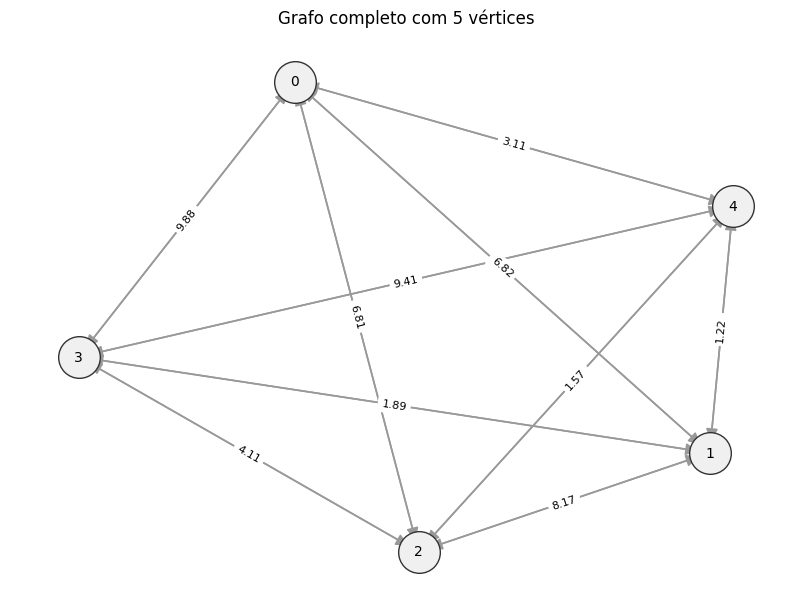

In [133]:
# Visualizar o grafo completo gerado
plotar_grafo(
    grafo_exemplo, 
    f"Grafo completo com {N_exemplo} vértices",
    "resultados/dijkstra/img/grafo_completo_exemplo.png"
)

### (b) Armazenar cada grafo em uma estrutura de dados (lista de adjacência)

Para cada valor de n, vamos gerar e armazenar o grafo completo em uma lista de adjacência. Os grafos podem ser guardados em uma lista para uso posterior nos experimentos.

In [134]:
# Gerar e armazenar grafos completos para experimentos
N_min = 4
N_max = 10  # Aumente conforme necessário (ex: 100, 1000, etc.)

grafos_completos = [gerar_grafo_completo(n) for n in range(N_min, N_max + 1)]
ns = list(range(N_min, N_max + 1))

print(f"{len(grafos_completos)} grafos completos gerados (n={N_min} até n={N_max})")

7 grafos completos gerados (n=4 até n=10)


In [135]:
# Salvar cada grafo completo em arquivo TXT
pasta_out = garantir_pasta_saida("resultados/dijkstra")
for idx, grafo in zip(ns, grafos_completos):
    salvar_grafo_txt(grafo, f"{pasta_out}/grafo_completo_n{idx}.txt", idx)

[OK] Grafo salvo: resultados/dijkstra/grafo_completo_n4.txt
[OK] Grafo salvo: resultados/dijkstra/grafo_completo_n5.txt
[OK] Grafo salvo: resultados/dijkstra/grafo_completo_n6.txt
[OK] Grafo salvo: resultados/dijkstra/grafo_completo_n7.txt
[OK] Grafo salvo: resultados/dijkstra/grafo_completo_n8.txt
[OK] Grafo salvo: resultados/dijkstra/grafo_completo_n9.txt
[OK] Grafo salvo: resultados/dijkstra/grafo_completo_n10.txt


### (c) Aplicar o algoritmo de Dijkstra em cada grafo gerado

Para cada grafo completo armazenado, vamos aplicar o algoritmo de Dijkstra considerando o vértice 0 como origem.

In [136]:
# Aplicar Dijkstra em cada grafo completo gerado (origem = 0)
resultados_dijkstra = [dijkstra_count(grafo, s=0) for grafo in grafos_completos]
comparacoes = [res.comparisons for res in resultados_dijkstra]

print(f"Dijkstra aplicado em {len(resultados_dijkstra)} grafos (origem=0)")
print("\nn\tcomparações")
for n, comp in zip(ns, comparacoes):
    print(f"{n}\t{comp}")

Dijkstra aplicado em 7 grafos (origem=0)

n	comparações
4	12
5	20
6	30
7	42
8	56
9	72
10	90


In [137]:
# Salvar resultados do Dijkstra em TXT
pasta_out = garantir_pasta_saida("resultados/dijkstra")
for idx, resultado in zip(ns, resultados_dijkstra):
    salvar_resultado_txt(resultado, f"{pasta_out}/resultado_dijkstra_n{idx}.txt")

[OK] Resultado salvo: resultados/dijkstra/resultado_dijkstra_n4.txt
[OK] Resultado salvo: resultados/dijkstra/resultado_dijkstra_n5.txt
[OK] Resultado salvo: resultados/dijkstra/resultado_dijkstra_n6.txt
[OK] Resultado salvo: resultados/dijkstra/resultado_dijkstra_n7.txt
[OK] Resultado salvo: resultados/dijkstra/resultado_dijkstra_n8.txt
[OK] Resultado salvo: resultados/dijkstra/resultado_dijkstra_n9.txt
[OK] Resultado salvo: resultados/dijkstra/resultado_dijkstra_n10.txt


### (d) Contar o número de comparações realizadas para cada grafo de entrada

Vamos extrair o número de comparações realizadas pelo Dijkstra em cada grafo e exibir uma tabela com o número de vértices e o número de comparações.

In [138]:
# Salvar tabela de comparações e instâncias
pasta_out = garantir_pasta_saida("resultados/dijkstra")
salvar_tabela_txt("n\tcomparacoes", list(zip(ns, comparacoes)), f"{pasta_out}/dijkstra_comparacoes.txt")

# Salvar instâncias em formato EWD
for idx, grafo in zip(ns, grafos_completos):
    salvar_instancia_ewd(grafo, f"{pasta_out}/instancia_n{idx}.txt")

[OK] Tabela salva: resultados/dijkstra/dijkstra_comparacoes.txt
[OK] Instância salva: resultados/dijkstra/instancia_n4.txt
[OK] Instância salva: resultados/dijkstra/instancia_n5.txt
[OK] Instância salva: resultados/dijkstra/instancia_n6.txt
[OK] Instância salva: resultados/dijkstra/instancia_n7.txt
[OK] Instância salva: resultados/dijkstra/instancia_n8.txt
[OK] Instância salva: resultados/dijkstra/instancia_n9.txt
[OK] Instância salva: resultados/dijkstra/instancia_n10.txt


### (e) Plotar gráfico: número de vértices (n) vs número de comparações

Vamos plotar o gráfico solicitado, usando Matplotlib, com Eixo X = número de vértices (n) e Eixo Y = número de comparações.

[OK] Gráfico salvo: resultados/dijkstra/img/dijkstra_comparacoes.png


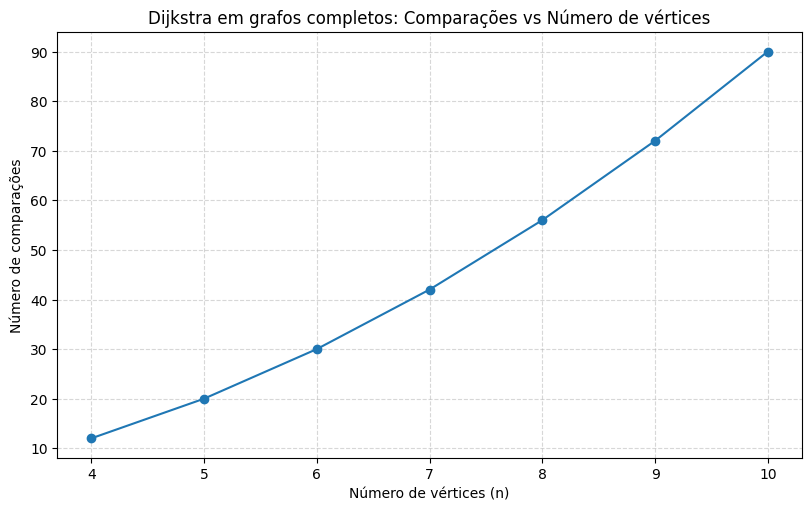

In [139]:
# Plotar gráfico: n vs comparações (Dijkstra)
plotar_comparacoes(
    ns, comparacoes,
    "Dijkstra em grafos completos: Comparações vs Número de vértices",
    "resultados/dijkstra/img/dijkstra_comparacoes.png",
    cor='tab:blue'
)

### (f) Aplicar o algoritmo em duas instâncias grandes (10.000 e 1.000.000 vértices)

Nesta etapa vamos usar as instâncias fornecidas no Moodle (formato EWD):
- "D:\\OneDrive\\Pessoais\\Doutorado\\Cefet\\022025\\Teoria de Grafos\\10000.txt"
- "D:\\OneDrive\\Pessoais\\Doutorado\\Cefet\\022025\\Teoria de Grafos\\largeEWD - contains one million vertices and 15172126 edges.txt"

Origem fixa no vértice 0. Reportaremos o número de comparações e tempos de carga/execução. A execução da instância de 1.000.000 é protegida por flag para evitar travamentos acidentais.

In [140]:
# Executar Dijkstra em instâncias grandes (10k e 1M)
caminho_10k = r"D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt"
caminho_1m = r"D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\largeEWD - contains one million vertices and 15172126 edges.txt"

# Instância 10.000 vértices
res_10k = executar_instancia(caminho_10k, dijkstra_count, origem=0, nome="Instância 10.000")

# Instância 1.000.000 vértices (altere RUN_1M para True para executar)
RUN_1M = False
res_1m = None
if RUN_1M:
    res_1m = executar_instancia(caminho_1m, dijkstra_count, origem=0, nome="Instância 1.000.000")


Carregando Instância 10.000...
Grafo carregado: V=10000 | tempo: 0.36s
Executando algoritmo (origem=0)...
Comparações: 123,462 | tempo: 0.15s
Grafo carregado: V=10000 | tempo: 0.36s
Executando algoritmo (origem=0)...
Comparações: 123,462 | tempo: 0.15s


---
# PARTE 2 — HEURÍSTICA GULOSA
---

## Parte 2 - I. Implementação da Heurística Gulosa

Heurística escolhida: um único varrimento de relaxamento sobre todas as arestas (ordem fixa da lista de adjacência). É uma aproximação do caminho mínimo por origem única — não garante otimalidade, mas é simples, linear no número de arestas e adequada para comparação experimental. A contagem de comparações corresponde ao número de verificações da condição de relaxamento (dist[u] + w < dist[v]).

### (a) Gerar grafos completos com pesos estritamente positivos

Vamos gerar grafos completos com número de vértices variando de 4 até N, atribuindo pesos aleatórios estritamente positivos (w > 0) para cada aresta. Reutilizaremos a função `gerar_grafo_completo(n)` já definida na Parte 1.

In [141]:
# Exemplo: gerar e visualizar grafo para heurística gulosa
N_exemplo_gulosa = 5
grafo_exemplo_gulosa = gerar_grafo_completo(N_exemplo_gulosa)

print(f"Grafo completo (heurística) com {N_exemplo_gulosa} vértices:")
for u in grafo_exemplo_gulosa:
    print(f"{u}: {[f'{v}(w={w:.2f})' for v, w in grafo_exemplo_gulosa[u]]}")

Grafo completo (heurística) com 5 vértices:
0: ['1(w=9.65)', '2(w=1.42)', '3(w=3.18)', '4(w=7.43)']
1: ['0(w=8.68)', '2(w=8.55)', '3(w=6.96)', '4(w=7.03)']
2: ['0(w=2.17)', '1(w=8.15)', '3(w=5.09)', '4(w=8.19)']
3: ['0(w=1.53)', '1(w=2.67)', '2(w=2.47)', '4(w=8.84)']
4: ['0(w=6.61)', '1(w=7.70)', '2(w=1.18)', '3(w=2.06)']


### (b) Armazenar cada grafo em uma estrutura de dados (lista de adjacência)

Para cada valor de n, vamos gerar e armazenar o grafo completo em uma lista de adjacência (`Adj`) para uso nos experimentos da heurística.

[OK] Imagem salva: resultados/gulosa/img/grafo_completo_exemplo.png


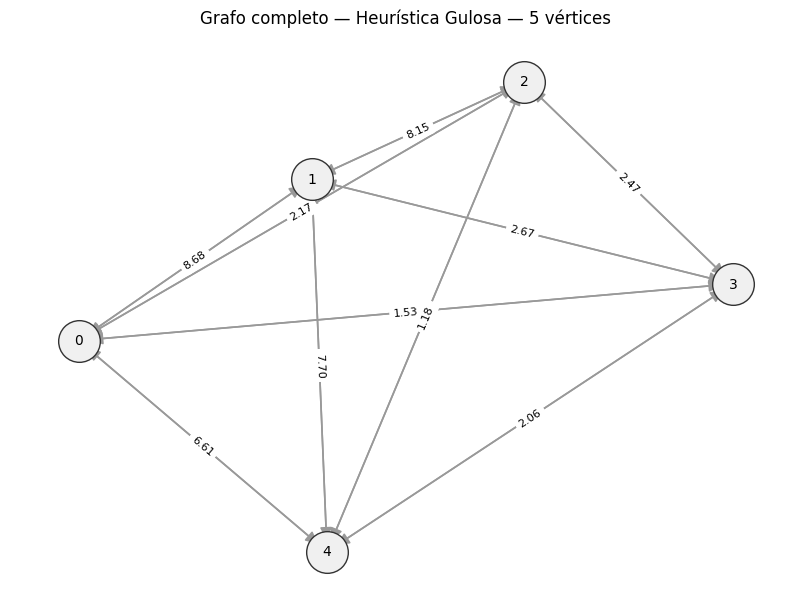

In [142]:
# Visualizar grafo completo (Gulosa)
plotar_grafo(
    grafo_exemplo_gulosa,
    f"Grafo completo — Heurística Gulosa — {N_exemplo_gulosa} vértices",
    "resultados/gulosa/img/grafo_completo_exemplo.png"
)

In [143]:
# Gerar grafos para heurística gulosa (reutiliza N_min e N_max)
grafos_gulosa = [gerar_grafo_completo(n) for n in range(N_min, N_max + 1)]
ns_gulosa = list(range(N_min, N_max + 1))

print(f"{len(grafos_gulosa)} grafos completos gerados para gulosa (n={N_min} até n={N_max})")

7 grafos completos gerados para gulosa (n=4 até n=10)


In [144]:
# Salvar grafos completos (Gulosa)
pasta_out = garantir_pasta_saida("resultados/gulosa")
for idx, grafo in zip(ns_gulosa, grafos_gulosa):
    salvar_grafo_txt(grafo, f"{pasta_out}/grafo_completo_n{idx}.txt", idx)

[OK] Grafo salvo: resultados/gulosa/grafo_completo_n4.txt
[OK] Grafo salvo: resultados/gulosa/grafo_completo_n5.txt
[OK] Grafo salvo: resultados/gulosa/grafo_completo_n6.txt
[OK] Grafo salvo: resultados/gulosa/grafo_completo_n7.txt
[OK] Grafo salvo: resultados/gulosa/grafo_completo_n8.txt
[OK] Grafo salvo: resultados/gulosa/grafo_completo_n9.txt
[OK] Grafo salvo: resultados/gulosa/grafo_completo_n10.txt


### (c) Aplicar a heurística em cada grafo gerado

Para cada grafo completo armazenado, vamos aplicar a heurística considerando o vértice 0 como origem.

In [145]:
# Aplicar heurística gulosa em cada grafo (origem = 0)
resultados_gulosa = [heuristica_gulosa(grafo, s=0) for grafo in grafos_gulosa]
comparacoes_gulosa = [res.comparisons for res in resultados_gulosa]

print(f"Heurística aplicada em {len(resultados_gulosa)} grafos (origem=0)")
print("\nn\tcomparações")
for n, comp in zip(ns_gulosa, comparacoes_gulosa):
    print(f"{n}\t{comp}")

Heurística aplicada em 7 grafos (origem=0)

n	comparações
4	12
5	20
6	30
7	42
8	56
9	72
10	90


In [146]:
# Salvar resultados da heurística gulosa
pasta_out = garantir_pasta_saida("resultados/gulosa")
for idx, resultado in zip(ns_gulosa, resultados_gulosa):
    salvar_resultado_txt(resultado, f"{pasta_out}/resultado_gulosa_n{idx}.txt")

[OK] Resultado salvo: resultados/gulosa/resultado_gulosa_n4.txt
[OK] Resultado salvo: resultados/gulosa/resultado_gulosa_n5.txt
[OK] Resultado salvo: resultados/gulosa/resultado_gulosa_n6.txt
[OK] Resultado salvo: resultados/gulosa/resultado_gulosa_n7.txt
[OK] Resultado salvo: resultados/gulosa/resultado_gulosa_n8.txt
[OK] Resultado salvo: resultados/gulosa/resultado_gulosa_n9.txt
[OK] Resultado salvo: resultados/gulosa/resultado_gulosa_n10.txt


### (d) Contar o número de comparações realizadas para cada grafo de entrada

Vamos extrair o número de comparações realizadas pela heurística em cada grafo e exibir uma tabela com o número de vértices e o número de comparações.

In [147]:
# Salvar tabela de comparações e instâncias (Gulosa)
pasta_out = garantir_pasta_saida("resultados/gulosa")
salvar_tabela_txt("n\tcomparacoes", list(zip(ns_gulosa, comparacoes_gulosa)), f"{pasta_out}/gulosa_comparacoes.txt")

# Salvar instâncias em formato EWD
for idx, grafo in zip(ns_gulosa, grafos_gulosa):
    salvar_instancia_ewd(grafo, f"{pasta_out}/instancia_n{idx}.txt")

[OK] Tabela salva: resultados/gulosa/gulosa_comparacoes.txt
[OK] Instância salva: resultados/gulosa/instancia_n4.txt
[OK] Instância salva: resultados/gulosa/instancia_n5.txt
[OK] Instância salva: resultados/gulosa/instancia_n6.txt
[OK] Instância salva: resultados/gulosa/instancia_n7.txt
[OK] Instância salva: resultados/gulosa/instancia_n8.txt
[OK] Instância salva: resultados/gulosa/instancia_n9.txt
[OK] Instância salva: resultados/gulosa/instancia_n10.txt
[OK] Instância salva: resultados/gulosa/instancia_n4.txt
[OK] Instância salva: resultados/gulosa/instancia_n5.txt
[OK] Instância salva: resultados/gulosa/instancia_n6.txt
[OK] Instância salva: resultados/gulosa/instancia_n7.txt
[OK] Instância salva: resultados/gulosa/instancia_n8.txt
[OK] Instância salva: resultados/gulosa/instancia_n9.txt
[OK] Instância salva: resultados/gulosa/instancia_n10.txt


### (e) Plotar gráfico: n (vértices) vs comparações (heurística)  — N ≤ 1.000.000

[OK] Gráfico salvo: resultados/gulosa/img/gulosa_comparacoes.png


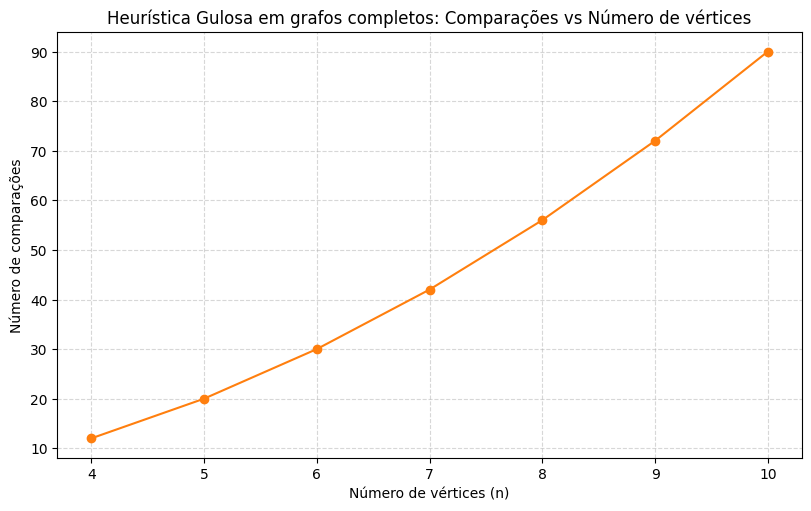

In [148]:
# Plotar gráfico: n vs comparações (Gulosa)
plotar_comparacoes(
    ns_gulosa, comparacoes_gulosa,
    "Heurística Gulosa em grafos completos: Comparações vs Número de vértices",
    "resultados/gulosa/img/gulosa_comparacoes.png",
    cor='tab:orange'
)

### (f) Instâncias do Moodle — 10.000 e 1.000.000 de vértices (origem = 0) — Heurística Gulosa

In [149]:
# Executar Heurística Gulosa em instâncias grandes (10k e 1M)
# Instância 10.000 vértices
res_g_10k = executar_instancia(caminho_10k, heuristica_gulosa, origem=0, nome="Instância 10.000 (Gulosa)")

# Instância 1.000.000 vértices
res_g_1m = None
if RUN_1M:
    res_g_1m = executar_instancia(caminho_1m, heuristica_gulosa, origem=0, nome="Instância 1.000.000 (Gulosa)")


Carregando Instância 10.000 (Gulosa)...
Grafo carregado: V=10000 | tempo: 0.50s
Executando algoritmo (origem=0)...
Comparações: 123,462 | tempo: 0.07s
Grafo carregado: V=10000 | tempo: 0.50s
Executando algoritmo (origem=0)...
Comparações: 123,462 | tempo: 0.07s


COMPARAÇÃO: DIJKSTRA vs HEURÍSTICA GULOSA

     n |     Dijkstra |       Gulosa |    Razão D/G
----------------------------------------------------------------------
     4 |           12 |           12 |         1.00
     5 |           20 |           20 |         1.00
     6 |           30 |           30 |         1.00
     7 |           42 |           42 |         1.00
     8 |           56 |           56 |         1.00
     9 |           72 |           72 |         1.00
    10 |           90 |           90 |         1.00

[OK] Gráfico comparativo salvo: resultados/comparacao_dijkstra_vs_gulosa.png

[OK] Gráfico comparativo salvo: resultados/comparacao_dijkstra_vs_gulosa.png


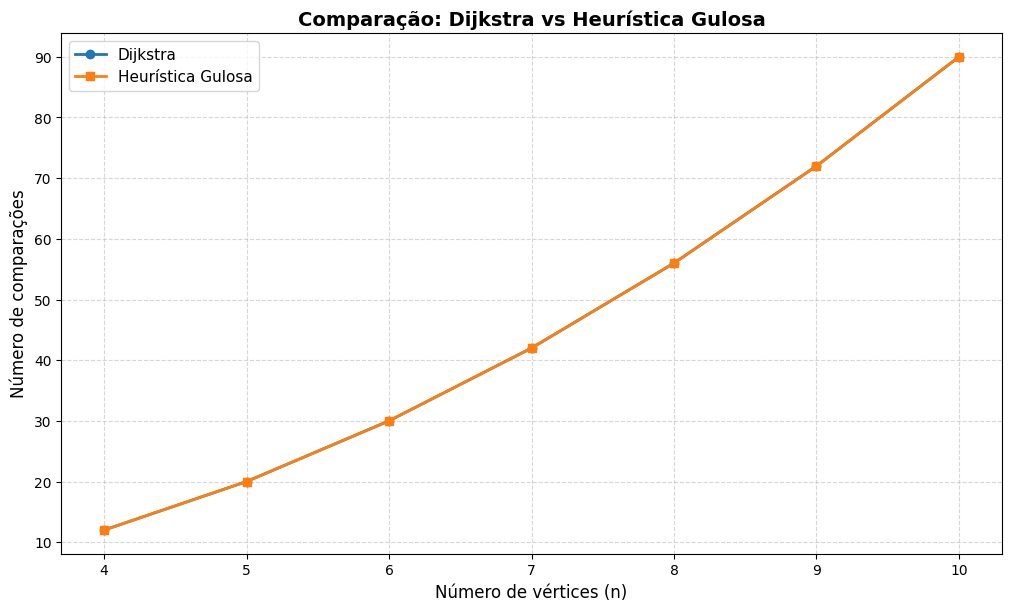

In [150]:
# Comparação final: Dijkstra vs Heurística Gulosa
print("="*70)
print("COMPARAÇÃO: DIJKSTRA vs HEURÍSTICA GULOSA")
print("="*70)

if len(ns) == len(ns_gulosa):
    print(f"\n{'n':>6} | {'Dijkstra':>12} | {'Gulosa':>12} | {'Razão D/G':>12}")
    print("-"*70)
    for i, n in enumerate(ns):
        d_comp = comparacoes[i]
        g_comp = comparacoes_gulosa[i]
        razao = d_comp / g_comp if g_comp > 0 else float('inf')
        print(f"{n:>6} | {d_comp:>12,} | {g_comp:>12,} | {razao:>12.2f}")
else:
    print("Tamanhos diferentes de arrays - execute os experimentos com mesmo N_min e N_max")

# Plotar comparação em gráfico único
fig = plt.figure(figsize=(10, 6), constrained_layout=True)
plt.plot(ns, comparacoes, marker='o', color='tab:blue', label='Dijkstra', linewidth=2)
plt.plot(ns_gulosa, comparacoes_gulosa, marker='s', color='tab:orange', label='Heurística Gulosa', linewidth=2)
plt.xlabel('Número de vértices (n)', fontsize=12)
plt.ylabel('Número de comparações', fontsize=12)
plt.title('Comparação: Dijkstra vs Heurística Gulosa', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Salvar comparação
pasta_img = garantir_pasta_saida("resultados")
fig.savefig(f"{pasta_img}/comparacao_dijkstra_vs_gulosa.png", dpi=150, bbox_inches='tight')
print(f"\n[OK] Gráfico comparativo salvo: {pasta_img}/comparacao_dijkstra_vs_gulosa.png")

plt.show()